# RNA Velocity from a Dynamical Systems Perspective

This notebook is a hands-on companion to the lecture *RNA Velocity: A Dynamical Systems Perspective*.
We build the idea from the ground up and **run** every piece:

1. **The two-state kinetic model** — the ODEs $\dot u=\alpha-\beta u,\ \dot s=\beta u-\gamma s$ and their exact solution.
2. **Phase portraits** — nullclines, the steady-state line, the vector field, the stable node.
3. **$\alpha^{\mathrm{on}}/\alpha^{\mathrm{off}}$** — how switching transcription on and off traces the induction/repression *loop* (animated).
4. **RNA velocity** — $v=\dot s$ as the signed distance from the steady-state line.
5. **The stochastic extension** — the chemical master equation, exact Gillespie simulation, and the product-form Poisson steady state (animated ensemble).
6. **Multiple genes** — assembling per-gene velocities into a vector field on a low-dimensional cell-state manifold.
7. **Estimation** — the *minimal* math for (a) the steady-state regression of La Manno et al. and (b) the EM / dynamical model of scVelo, with the fit **animated over EM iterations**.
8. **Identifiability** — why "velocity" is only known up to a time scale.

> Throughout we set the splicing rate $\beta=1$ (a choice of time unit) unless stated otherwise. Everything here is self-contained: `numpy`, `scipy`, `matplotlib`.

**Key references:** La Manno et al. 2018 (steady-state model); Bergen et al. 2020 (scVelo / dynamical model); Gorin, Fang, Chari & Pachter 2022 and Gorin & Pachter 2022 (biophysical foundations & critique); Qiu et al. 2022 (Dynamo); Gayoso et al. 2024 (veloVI); Lange et al. 2022 (CellRank); Schiebinger et al. 2019 (Waddington-OT).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import base64
from IPython.display import HTML, display

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
RNG = np.random.default_rng(0)

# colours used consistently throughout
C_IND, C_REP, C_DET, C_FIT, C_TRUE = "#c1432e", "#2e7d6b", "#1f3b73", "#d98a00", "#222222"

def show_gif(path, width=760):
    "Embed an animated GIF as a self-contained data-URI so it persists in the .ipynb."
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    return HTML(f'<img src="data:image/gif;base64,{b64}" width="{width}">')

print("environment ready")

environment ready


## 1. The two-state kinetic model

A gene is transcribed as **unspliced** mRNA $u$, spliced into **mature** mRNA $s$, then degraded:

$$\varnothing \xrightarrow{\;\alpha\;} u \xrightarrow{\;\beta\;} s \xrightarrow{\;\gamma\;} \varnothing
\qquad\Longrightarrow\qquad
\dot u=\alpha-\beta u,\qquad \dot s=\beta u-\gamma s .$$

**Deriving the solution (integrating factor).**
The $u$-equation is linear first order, $\dot u+\beta u=\alpha$. Multiply by $e^{\beta t}$ so the left side is an exact derivative:
$$\frac{d}{dt}\!\big(u\,e^{\beta t}\big)=\alpha e^{\beta t}\ \Rightarrow\ u\,e^{\beta t}=\tfrac{\alpha}{\beta}e^{\beta t}+C .$$
With $u(0)=u_0$ this gives, writing $u_\infty=\alpha/\beta$,
$$\boxed{\,u(t)=u_\infty+(u_0-u_\infty)e^{-\beta t}\,}.$$
Substitute into the $s$-equation, $\dot s+\gamma s=\beta u(t)=\gamma s_\infty+\beta(u_0-u_\infty)e^{-\beta t}$ (using $\beta u_\infty=\alpha=\gamma s_\infty$, $s_\infty=\alpha/\gamma$). Multiply by $e^{\gamma t}$ and integrate:
$$\frac{d}{dt}\!\big(s\,e^{\gamma t}\big)=\gamma s_\infty e^{\gamma t}+\beta(u_0-u_\infty)e^{(\gamma-\beta)t}.$$
Integrating ($\gamma\neq\beta$) and fixing $C$ from $s(0)=s_0$:
$$\boxed{\,s(t)=s_\infty+(s_0-s_\infty)e^{-\gamma t}+\frac{\beta(u_0-u_\infty)}{\gamma-\beta}\big(e^{-\beta t}-e^{-\gamma t}\big)\,}.$$

**Resonant case $\gamma=\beta$.** The factor $\frac{e^{-\beta t}-e^{-\gamma t}}{\gamma-\beta}$ is a difference quotient in $\gamma$; as $\gamma\to\beta$ it tends to $-\frac{\partial}{\partial\gamma}e^{-\gamma t}\big|_{\gamma=\beta}=t\,e^{-\beta t}$, so the last term becomes $\beta(u_0-u_\infty)\,t\,e^{-\beta t}$.

Below we implement this and confirm it against a numerical integrator (agreement $\sim10^{-9}$).

max |analytic - numeric| = 1.2134853122347522e-09


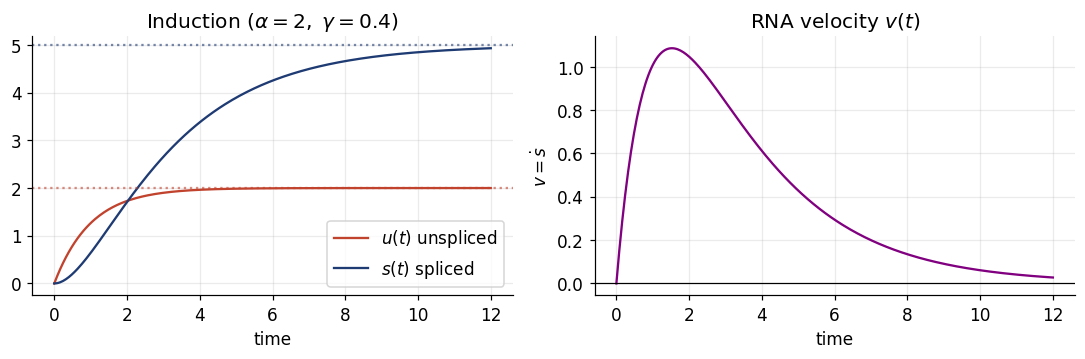

In [2]:
def solve_us(t, alpha, beta, gamma, u0=0.0, s0=0.0):
    "Exact solution of the two-state ODE. Handles the resonant case gamma==beta."
    t = np.asarray(t, float)
    u_inf, s_inf = alpha / beta, alpha / gamma
    u = u_inf + (u0 - u_inf) * np.exp(-beta * t)
    if abs(gamma - beta) < 1e-8:                       # resonant limit
        s = s_inf + (s0 - s_inf) * np.exp(-gamma * t) \
            + beta * (u0 - u_inf) * t * np.exp(-beta * t)
    else:
        s = s_inf + (s0 - s_inf) * np.exp(-gamma * t) \
            + beta * (u0 - u_inf) / (gamma - beta) * (np.exp(-beta * t) - np.exp(-gamma * t))
    return u, s

# --- verify against a numerical ODE solver ---
alpha, beta, gamma = 2.0, 1.0, 0.4
tt = np.linspace(0, 12, 300)
num = solve_ivp(lambda t, y: [alpha - beta*y[0], beta*y[0] - gamma*y[1]],
                (0, 12), [0, 0], t_eval=tt, rtol=1e-9, atol=1e-12)
ua, sa = solve_us(tt, alpha, beta, gamma)
print("max |analytic - numeric| =", np.max(np.abs([ua - num.y[0], sa - num.y[1]])))

# --- plot one induction trajectory and its velocity ---
v = beta*ua - gamma*sa
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(tt, ua, label="$u(t)$ unspliced", color=C_IND)
ax[0].plot(tt, sa, label="$s(t)$ spliced",  color=C_DET)
ax[0].axhline(alpha/beta, ls=":", color=C_IND, alpha=.6)
ax[0].axhline(alpha/gamma, ls=":", color=C_DET, alpha=.6)
ax[0].set_xlabel("time"); ax[0].set_title("Induction ($\\alpha=2,\\ \\gamma=0.4$)"); ax[0].legend()
ax[1].plot(tt, v, color="purple"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_xlabel("time"); ax[1].set_ylabel("$v=\\dot s$"); ax[1].set_title("RNA velocity $v(t)$")
plt.tight_layout(); plt.show()

The analytic solution matches the integrator to ~$10^{-9}$. Note the mechanism that makes velocity work: **$u$ relaxes faster than $s$** (here $\beta=1>\gamma=0.4$), so the unspliced pool *leads* the spliced pool. The velocity $v=\dot s$ is large and positive early in induction and decays to zero as the gene approaches steady state.

## 2. Phase portrait, nullclines, and stability

**Nullclines** are where each component of the field vanishes:
$$\dot u=0\iff u=\tfrac{\alpha}{\beta}\ \text{(horizontal)},\qquad
\dot s=0\iff \beta u-\gamma s=0\iff u=\tfrac{\gamma}{\beta}s\ \text{(the *steady-state line*).}$$
Their intersection is the fixed point: $u^\ast=\alpha/\beta$, hence $s^\ast=\tfrac{\beta}{\gamma}u^\ast=\alpha/\gamma$, i.e. $(s^\ast,u^\ast)=(\alpha/\gamma,\ \alpha/\beta)$.

**Stability.** The field is affine, $\dot x=Jx+b$ with the *constant* Jacobian
$$J=\begin{pmatrix}-\beta&0\\[1pt]\beta&-\gamma\end{pmatrix}.$$
Since $J$ is lower-triangular, $\det(J-\lambda I)=(-\beta-\lambda)(-\gamma-\lambda)=0$ gives the eigenvalues straight off the diagonal,
$$\lambda_1=-\beta,\qquad \lambda_2=-\gamma\quad(<0).$$
Both are real and negative $\Rightarrow$ a **stable node**; and because $J$ is constant the linearization is *exact*, so this equilibrium is the unique, **globally** attracting state for fixed $\alpha$. The eigenvectors are $v_1\propto(\gamma-\beta,\ \beta)$ (for $\lambda_1$) and $v_2\propto(0,1)$ (for $\lambda_2$): $u$ decays on timescale $1/\beta$, $s$ on timescale $1/\gamma$. The unspliced pool equilibrates first and the spliced pool follows — the **lag** that RNA velocity reads off.

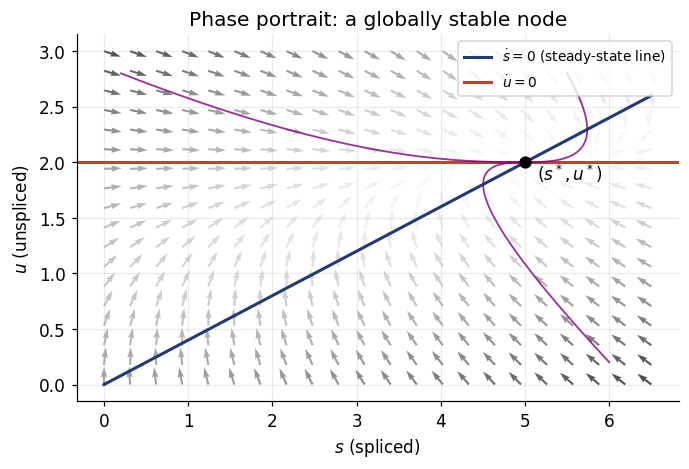

In [3]:
alpha, beta, gamma = 2.0, 1.0, 0.4
u_star, s_star = alpha/beta, alpha/gamma

# vector field on a grid (axes: s horizontal, u vertical)
S, U = np.meshgrid(np.linspace(0, 6.5, 22), np.linspace(0, 3.0, 18))
dU = alpha - beta*U
dS = beta*U - gamma*S
mag = np.hypot(dU, dS) + 1e-9

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.quiver(S, U, dS/mag, dU/mag, mag, cmap="Greys", scale=34, width=.0035, alpha=.7)
# nullclines
s_line = np.linspace(0, 6.5, 50)
ax.plot(s_line, (gamma/beta)*s_line, color=C_DET, lw=2, label="$\\dot s=0$ (steady-state line)")
ax.axhline(alpha/beta, color=C_IND, lw=2, label="$\\dot u=0$")
# a couple of trajectories
for s0, u0 in [(6, 0.2), (0.2, 2.8), (5.5, 2.8)]:
    tt = np.linspace(0, 30, 600)
    uu, ss = solve_us(tt, alpha, beta, gamma, u0=u0, s0=s0)
    ax.plot(ss, uu, color="purple", lw=1.2, alpha=.8)
ax.plot(*[s_star, u_star], "o", color="k", ms=7); ax.annotate("$(s^*,u^*)$", (s_star, u_star),
        textcoords="offset points", xytext=(8, -12))
ax.set_xlabel("$s$ (spliced)"); ax.set_ylabel("$u$ (unspliced)")
ax.set_title("Phase portrait: a globally stable node"); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

## 3. $\alpha^{\mathrm{on}}/\alpha^{\mathrm{off}}$ — the induction/repression loop

A single fixed $\alpha$ is dynamically dull (one stable point). Real genes **switch**. Set $\beta=1$.

**Induction** ($\alpha=\alpha^{\mathrm{on}}$ from $(0,0)$). Putting $u_0=s_0=0$, $u_\infty=\alpha^{\mathrm{on}}$, $s_\infty=\alpha^{\mathrm{on}}/\gamma$ into §1 ($\gamma\neq1$; $\gamma=1$ is the resonant limit):
$$u_{\mathrm{ind}}(t)=\alpha^{\mathrm{on}}\!\left(1-e^{-t}\right),\qquad
s_{\mathrm{ind}}(t)=\tfrac{\alpha^{\mathrm{on}}}{\gamma}\!\left(1-e^{-\gamma t}\right)-\tfrac{\alpha^{\mathrm{on}}}{\gamma-1}\!\left(e^{-t}-e^{-\gamma t}\right).$$

**Repression** ($\alpha=0$). At the switch time $t_s$ the state is $(u_s,s_s)=(u_{\mathrm{ind}}(t_s),s_{\mathrm{ind}}(t_s))$. With $\alpha=0$ both asymptotes are $0$; letting $\tau=t-t_s$,
$$u_{\mathrm{rep}}(\tau)=u_s\,e^{-\tau},\qquad
s_{\mathrm{rep}}(\tau)=s_s\,e^{-\gamma\tau}+\tfrac{u_s}{\gamma-1}\!\left(e^{-\tau}-e^{-\gamma\tau}\right).$$

**Why a loop?** Velocity is $v=u-\gamma s$, the gap to the steady-state line. During induction $u$ runs *ahead* of its steady ratio (it feeds $s$, which lags), so $u>\gamma s\Rightarrow v>0$: the path bows **above** the line. When $\alpha$ switches off, the source vanishes; $u$ collapses on timescale $1$ while $s$ lingers on timescale $1/\gamma$, so $u<\gamma s\Rightarrow v<0$: the path returns **below** the line. The two arcs meet at $(0,0)$ and at the switch point, enclosing the almond-shaped loop.

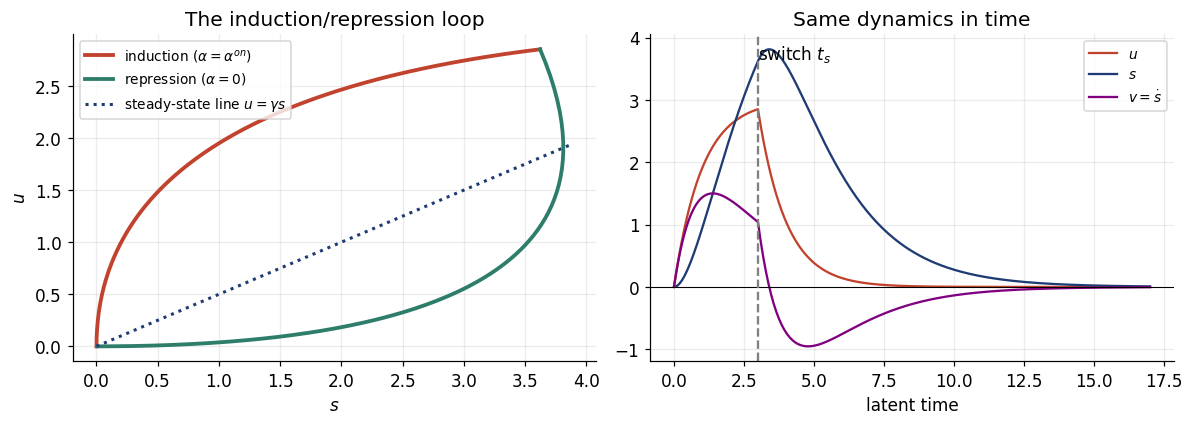

In [4]:
def model_curve(times, alpha_on, gamma, t_s, beta=1.0):
    "Induction for t<=t_s (from origin), repression for t>t_s. Returns u, s, phase(0/1)."
    times = np.asarray(times, float)
    u = np.empty_like(times); s = np.empty_like(times); phase = np.zeros(times.shape, int)
    ind = times <= t_s
    u[ind], s[ind] = solve_us(times[ind], alpha_on, beta, gamma, 0.0, 0.0)
    u_sw, s_sw = solve_us(np.array([t_s]), alpha_on, beta, gamma, 0.0, 0.0)
    rep = ~ind
    u[rep], s[rep] = solve_us(times[rep] - t_s, 0.0, beta, gamma, u_sw[0], s_sw[0])
    phase[rep] = 1
    return u, s, phase

alpha_on, gamma, t_s = 3.0, 0.5, 3.0
t_ind = np.linspace(0, t_s, 200)
t_rep = np.linspace(t_s, t_s + 14, 300)
ui, si, _ = model_curve(t_ind, alpha_on, gamma, t_s)
ur, sr, _ = model_curve(t_rep, alpha_on, gamma, t_s)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(si, ui, color=C_IND, lw=2.5, label="induction ($\\alpha=\\alpha^{on}$)")
ax[0].plot(sr, ur, color=C_REP, lw=2.5, label="repression ($\\alpha=0$)")
s_line = np.linspace(0, max(sr)*1.02, 50)
ax[0].plot(s_line, gamma*s_line, ":", color=C_DET, lw=2, label="steady-state line $u=\\gamma s$")
ax[0].set_xlabel("$s$"); ax[0].set_ylabel("$u$"); ax[0].set_title("The induction/repression loop"); ax[0].legend(fontsize=9)

t_all = np.concatenate([t_ind, t_rep])
u_all, s_all, _ = model_curve(t_all, alpha_on, gamma, t_s)
v_all = u_all - gamma*s_all
ax[1].plot(t_all, u_all, color=C_IND, label="$u$"); ax[1].plot(t_all, s_all, color=C_DET, label="$s$")
ax[1].plot(t_all, v_all, color="purple", label="$v=\\dot s$"); ax[1].axhline(0, color="k", lw=.7)
ax[1].axvline(t_s, ls="--", color="gray"); ax[1].annotate("switch $t_s$", (t_s, ax[1].get_ylim()[1]*.9))
ax[1].set_xlabel("latent time"); ax[1].set_title("Same dynamics in time"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### GIF 1 — a cell traveling around the loop

The left panel shows a single cell moving along the loop in the phase plane; the right panel shows the synchronized time courses of $u$, $s$, and the velocity $v$. Watch how $v>0$ exactly when the point is **above** the steady-state line and $v<0$ when it is **below**.


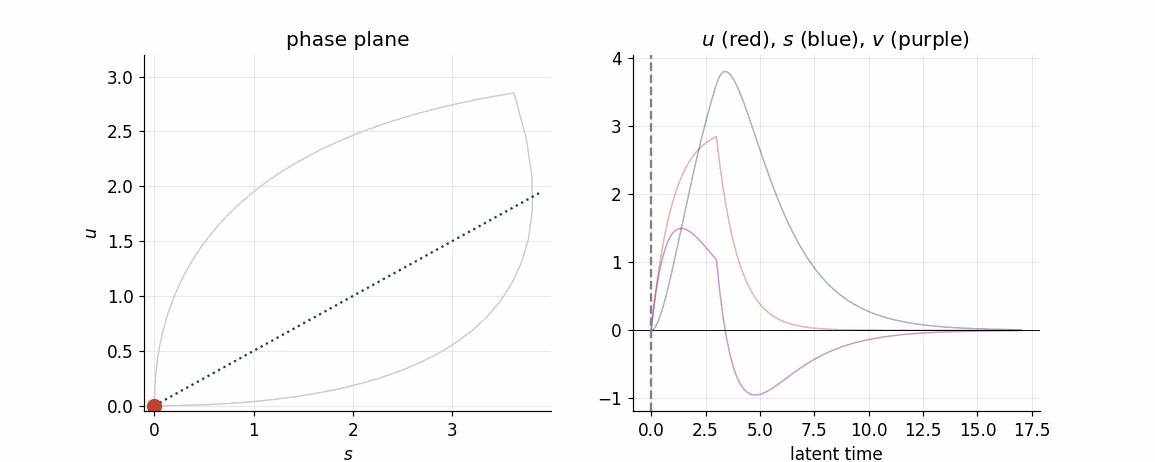

In [5]:
# pre-compute the full trajectory on a uniform-ish arc
t_path = np.concatenate([np.linspace(0, t_s, 60), np.linspace(t_s, t_s + 14, 90)])
up, sp, ph = model_curve(t_path, alpha_on, gamma, t_s)
vp = up - gamma*sp
nF = len(t_path)

fig, (axp, axt) = plt.subplots(1, 2, figsize=(10.5, 4.2))
# static backdrop
axp.plot(sp, up, color="0.8", lw=1)
sl = np.linspace(0, sp.max()*1.02, 50); axp.plot(sl, gamma*sl, ":", color=C_DET, lw=1.5)
axp.set_xlim(-0.1, sp.max()*1.05); axp.set_ylim(-0.05, up.max()*1.12)
axp.set_xlabel("$s$"); axp.set_ylabel("$u$"); axp.set_title("phase plane")
trail, = axp.plot([], [], lw=2.5)
dot,   = axp.plot([], [], "o", ms=9, color="k")

axt.plot(t_path, up, color=C_IND, lw=1, alpha=.4); axt.plot(t_path, sp, color=C_DET, lw=1, alpha=.4)
axt.plot(t_path, vp, color="purple", lw=1, alpha=.4); axt.axhline(0, color="k", lw=.6)
axt.set_xlabel("latent time"); axt.set_title("$u$ (red), $s$ (blue), $v$ (purple)")
lu, = axt.plot([], [], color=C_IND, lw=2.5); ls_, = axt.plot([], [], color=C_DET, lw=2.5)
lv, = axt.plot([], [], color="purple", lw=2.5); vline = axt.axvline(0, color="gray", ls="--")

def init():
    return trail, dot, lu, ls_, lv, vline
def upd(i):
    col = C_IND if ph[i] == 0 else C_REP
    trail.set_data(sp[:i+1], up[:i+1]); trail.set_color(col)
    dot.set_data([sp[i]], [up[i]]); dot.set_color(col)
    lu.set_data(t_path[:i+1], up[:i+1]); ls_.set_data(t_path[:i+1], sp[:i+1])
    lv.set_data(t_path[:i+1], vp[:i+1]); vline.set_xdata([t_path[i], t_path[i]])
    return trail, dot, lu, ls_, lv, vline

anim = FuncAnimation(fig, upd, init_func=init, frames=nF, interval=50, blit=False)
anim.save("01_induction_repression_loop.gif", writer=PillowWriter(fps=20))
plt.close(fig)
show_gif("01_induction_repression_loop.gif")

## 4. RNA velocity = signed distance from the steady-state line

By definition $v=\dot s=\beta u-\gamma s=\beta\big(u-\tfrac{\gamma}{\beta}s\big)$, and with $\beta=1$, $\;v=u-\gamma s$.

The steady-state line is $u=\gamma s$. For a cell at $(s,u)$, the point on the line *directly below it* (same $s$) is $(s,\gamma s)$, so the **vertical gap** is $u-\gamma s=v$. Thus velocity is exactly the signed vertical distance to the line (the perpendicular distance is $v/\sqrt{1+\gamma^2}$, same sign). Hence: **above** the line $\Rightarrow v>0$ (induction), **on** it $\Rightarrow v=0$, **below** it $\Rightarrow v<0$ (repression). That geometric fact is the whole content of "RNA velocity."

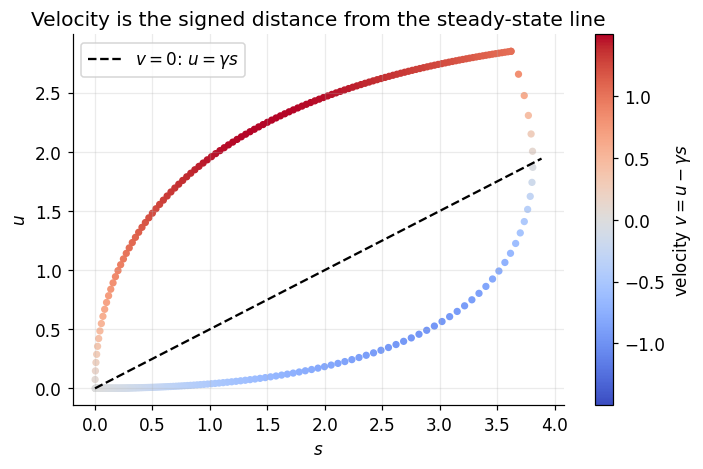

In [6]:
alpha_on, gamma, t_s = 3.0, 0.5, 3.0
t_path = np.concatenate([np.linspace(0, t_s, 120), np.linspace(t_s, t_s + 14, 200)])
u_, s_, _ = model_curve(t_path, alpha_on, gamma, t_s)
v_ = u_ - gamma*s_

fig, ax = plt.subplots(figsize=(6.6, 4.4))
sc = ax.scatter(s_, u_, c=v_, cmap="coolwarm", s=14,
                vmin=-np.abs(v_).max(), vmax=np.abs(v_).max())
sl = np.linspace(0, s_.max()*1.02, 50); ax.plot(sl, gamma*sl, "k--", lw=1.5, label="$v=0$: $u=\\gamma s$")
plt.colorbar(sc, label="velocity $v=u-\\gamma s$")
ax.set_xlabel("$s$"); ax.set_ylabel("$u$"); ax.set_title("Velocity is the signed distance from the steady-state line")
ax.legend(); plt.tight_layout(); plt.show()

## 5. The stochastic extension

The state is integer counts $(n_u,n_s)$ with three reactions: propensities $a_1=\alpha$ ($\varnothing\!\to\!u$), $a_2=\beta n_u$ ($u\!\to\!s$), $a_3=\gamma n_s$ ($s\!\to\!\varnothing$), and changes $\nu_1=(+1,0),\ \nu_2=(-1,+1),\ \nu_3=(0,-1)$. The **chemical master equation** balances probability flux:
$$\partial_t P(n_u,n_s)=\alpha\big[P(n_u{-}1,n_s)-P\big]+\beta\big[(n_u{+}1)P(n_u{+}1,n_s{-}1)-n_u P\big]+\gamma\big[(n_s{+}1)P(n_u,n_s{+}1)-n_s P\big].$$

**(a) The ODE is the *exact* mean.** For any jump process, $\dfrac{d}{dt}\mathbb E[g(X)]=\sum_r \mathbb E\!\big[a_r(X)\,(g(X+\nu_r)-g(X))\big]$. Take $g=n_u$ (changes $+1,-1,0$): $\;\dot{\mathbb E}[n_u]=\mathbb E[a_1]-\mathbb E[a_2]=\alpha-\beta\,\mathbb E[n_u]$. Take $g=n_s$ (changes $0,+1,-1$): $\;\dot{\mathbb E}[n_s]=\mathbb E[a_2]-\mathbb E[a_3]=\beta\,\mathbb E[n_u]-\gamma\,\mathbb E[n_s]$. Because every propensity is **linear**, $\mathbb E[a_r]=a_r(\mathbb E[X])$ and the moments *close*: the deterministic ODEs hold for the means with no approximation.

**(b) Stationary law is product-form Poisson.** The $u$-node is pure immigration–death (constant birth $\alpha$, per-molecule death $\beta$); its stationary law is $\mathrm{Poisson}(\alpha/\beta)$. By Burke's theorem its output is a Poisson stream of rate $\alpha$, which is the immigration into the $s$-node (birth $\alpha$, death $\gamma$) $\Rightarrow \mathrm{Poisson}(\alpha/\gamma)$, and the two nodes are **independent** (Jackson network). Hence
$$P_{\mathrm{ss}}(n_u,n_s)=\mathrm{Poisson}\!\big(n_u;\tfrac{\alpha}{\beta}\big)\,\mathrm{Poisson}\!\big(n_s;\tfrac{\alpha}{\gamma}\big),\qquad \text{Fano}=\tfrac{\mathrm{Var}}{\mathrm{mean}}=1,\ \ \mathrm{Cov}(u,s)=0.$$
(Real transcription is *bursty* — $\alpha$ itself switches — which over-disperses counts to Fano $>1$; that is why the bursty CME of Gorin & Pachter matters.)

**(c) Diffusion limit.** The chemical Langevin equation is $dX=S\,a(X)\,dt+S\,\mathrm{diag}(\sqrt{a})\,dW$ with stoichiometry $S=\big[\begin{smallmatrix}+1&-1&0\\0&+1&-1\end{smallmatrix}\big]$, giving diffusion matrix
$$D=S\,\mathrm{diag}(a)\,S^{\!\top}=\begin{pmatrix}\alpha+\beta u&-\beta u\\-\beta u&\beta u+\gamma s\end{pmatrix}$$
— state-dependent, with a **negative** $u$–$s$ covariance from the shared splicing reaction (a single additive shared noise would be the wrong, rank-one model).

We verify (a)–(b) by exact Gillespie simulation below.

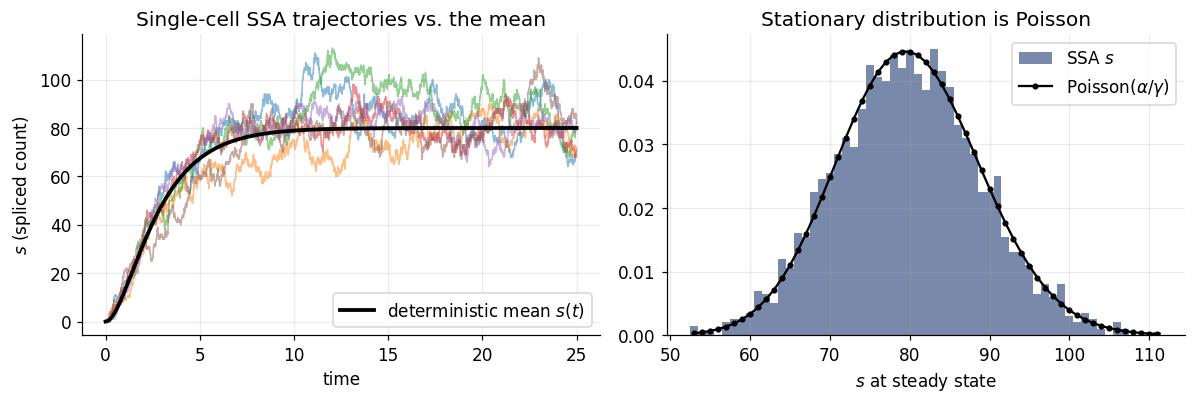

u:  mean=40.0 (a/b=40)  Fano=0.96
s:  mean=79.8 (a/g=80)  Fano=1.03
corr(u,s) = +0.020  (theory: 0)


In [7]:
def gillespie(alpha, beta, gamma, T, n0=(0, 0), rng=None):
    "Exact SSA for the birth-death-conversion network. Returns event times and counts."
    rng = rng or np.random.default_rng()
    t = 0.0; nu, ns = n0
    ts, us, ss = [0.0], [nu], [ns]
    while t < T:
        a = np.array([alpha, beta*nu, gamma*ns]); a0 = a.sum()
        if a0 <= 0:
            break
        t += rng.exponential(1.0/a0)
        r = rng.random()*a0
        if   r < a[0]:        nu += 1            # transcription
        elif r < a[0]+a[1]:   nu -= 1; ns += 1   # splicing
        else:                 ns -= 1            # degradation
        ts.append(min(t, T)); us.append(nu); ss.append(ns)
    return np.array(ts), np.array(us), np.array(ss)

A, B, G, T = 40.0, 1.0, 0.5, 25.0    # larger scale so the Poisson cloud is visible
rng = np.random.default_rng(1)

# a few single-cell trajectories vs the deterministic mean
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
tgrid = np.linspace(0, T, 300)
ud, sd = solve_us(tgrid, A, B, G)
for _ in range(6):
    ts, us, ss = gillespie(A, B, G, T, rng=rng)
    ax[0].step(ts, ss, where="post", alpha=.5, lw=1)
ax[0].plot(tgrid, sd, "k", lw=2.5, label="deterministic mean $s(t)$")
ax[0].set_xlabel("time"); ax[0].set_ylabel("$s$ (spliced count)")
ax[0].set_title("Single-cell SSA trajectories vs. the mean"); ax[0].legend()

# stationary distribution: independent Poisson
u_end, s_end = [], []
for _ in range(2000):
    ts, us, ss = gillespie(A, B, G, T, rng=rng)
    u_end.append(us[-1]); s_end.append(ss[-1])
u_end, s_end = np.array(u_end), np.array(s_end)
from scipy.stats import poisson
ax[1].hist(s_end, bins=np.arange(s_end.min(), s_end.max()+2)-.5, density=True,
           alpha=.6, color=C_DET, label="SSA $s$")
ks = np.arange(s_end.min(), s_end.max()+1)
ax[1].plot(ks, poisson.pmf(ks, A/G), "o-", color="k", ms=3, label="Poisson($\\alpha/\\gamma$)")
ax[1].set_xlabel("$s$ at steady state"); ax[1].set_title("Stationary distribution is Poisson"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"u:  mean={u_end.mean():.1f} (a/b={A/B:.0f})  Fano={u_end.var()/u_end.mean():.2f}")
print(f"s:  mean={s_end.mean():.1f} (a/g={A/G:.0f})  Fano={s_end.var()/s_end.mean():.2f}")
print(f"corr(u,s) = {np.corrcoef(u_end, s_end)[0,1]:+.3f}  (theory: 0)")

### GIF 2 — an ensemble of stochastic cells around the deterministic flow

Each dot is one cell evolving by the exact SSA during induction. The black curve is the deterministic (mean-field) trajectory. The cloud **follows the mean** and broadens into the stationary Poisson scatter — a direct picture of "the ODE is the mean, noise lives around it."


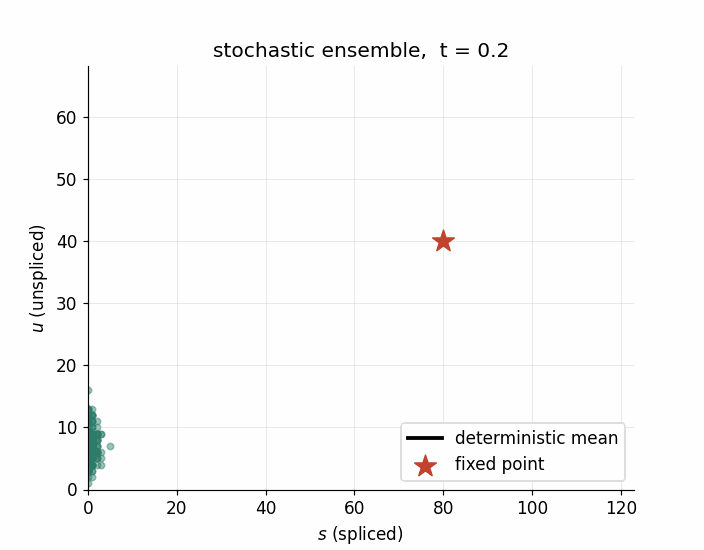

In [8]:
A, B, G, T = 40.0, 1.0, 0.5, 18.0
M = 220                                  # cells in the ensemble
rng = np.random.default_rng(7)
sims = [gillespie(A, B, G, T, rng=rng) for _ in range(M)]

frames = 80
tg = np.linspace(0.2, T, frames)
# piecewise-constant sample of each SSA at the common time grid
Us = np.zeros((M, frames)); Ss = np.zeros((M, frames))
for m, (ts, us, ss) in enumerate(sims):
    idx = np.searchsorted(ts, tg, side="right") - 1
    idx = np.clip(idx, 0, len(ts)-1)
    Us[m] = us[idx]; Ss[m] = ss[idx]

ud, sd = solve_us(tg, A, B, G)
fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.set_xlim(0, Ss.max()*1.05); ax.set_ylim(0, Us.max()*1.05)
ax.set_xlabel("$s$ (spliced)"); ax.set_ylabel("$u$ (unspliced)")
det_line, = ax.plot([], [], "k", lw=2.5, label="deterministic mean")
scat = ax.scatter([], [], s=18, alpha=.45, color=C_REP)
ax.scatter([A/G], [A/B], marker="*", s=220, color=C_IND, zorder=5, label="fixed point")
ax.legend(loc="lower right")
ttl = ax.set_title("")

def upd(i):
    scat.set_offsets(np.column_stack([Ss[:, i], Us[:, i]]))
    det_line.set_data(sd[:i+1], ud[:i+1])
    ttl.set_text(f"stochastic ensemble,  t = {tg[i]:.1f}")
    return scat, det_line, ttl

anim = FuncAnimation(fig, upd, frames=frames, interval=60, blit=False)
anim.save("02_stochastic_ensemble.gif", writer=PillowWriter(fps=18))
plt.close(fig)
show_gif("02_stochastic_ensemble.gif")

## 6. Multiple genes — a velocity field on the cell-state manifold

Stack $G$ genes. A cell is a point $x=(s_1,\dots,s_G)\in\mathbb R^G$ with companion unspliced vector $(u_1,\dots,u_G)$, and each gene contributes $v_g=u_g-\gamma_g s_g$, so the cell carries a **velocity vector** $v=(v_1,\dots,v_G)\in\mathbb R^G$. If the genes share one **latent time** $t$ (the cell's progress), then $x(t)$ traces a $1$-D curve — a manifold $\mathcal M\subset\mathbb R^G$ — and by the chain rule $v=\dfrac{dx}{dt}$ is its **tangent**: the $v_i$ are samples of a vector field on $\mathcal M$.

**Embedding the field.** To see it in 2-D we take the simplest faithful map: predict the near-future state with one Euler step $x^{+}=x+\Delta t\,v$, embed both with the *same* linear PCA projection $\pi$, and draw the arrow
$$\pi(x^{+})-\pi(x)=\Delta t\,\pi(v)\qquad(\pi\text{ linear }\Rightarrow\text{ it commutes with the displacement}),$$
so the arrow genuinely shows where the dynamics push the cell. We score it by the cosine between each arrow and the local direction of increasing latent time.

**From field to fates (what comes next).** In practice one turns the field into a row-stochastic transition matrix on the cell $k$-NN graph,
$$P_{ij}\ \propto\ \exp\!\Big(\tfrac{1}{\sigma}\cos\theta_{ij}\Big),\qquad \cos\theta_{ij}=\frac{v_i^{\!\top}(x_j-x_i)}{\|v_i\|\,\|x_j-x_i\|},$$
inducing a Markov chain whose absorption probabilities give cell-fate probabilities (CellRank).

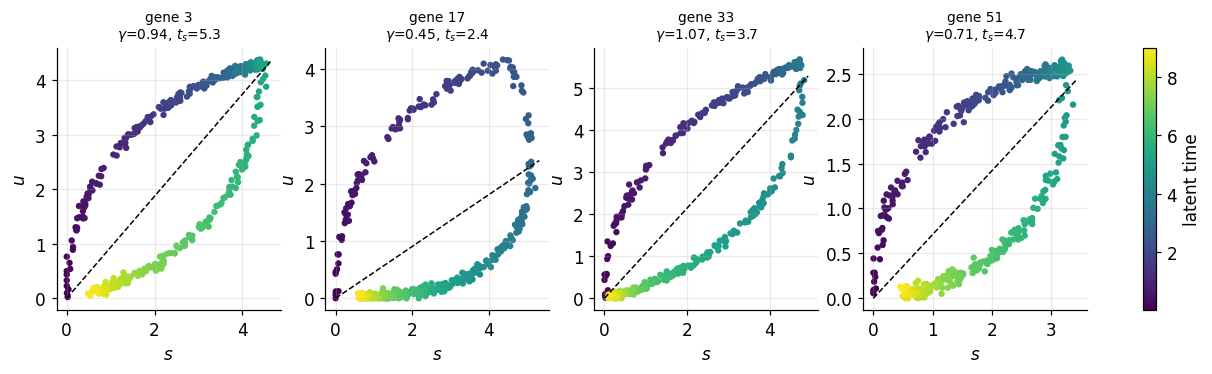

In [9]:
G = 60                                   # genes
N = 400                                  # cells
rngG = np.random.default_rng(3)
alpha_g = rngG.uniform(2, 6, G)
gamma_g = rngG.uniform(0.2, 1.5, G)
ts_g    = rngG.uniform(2, 6, G)
# shared latent time per cell, spanning induction and repression of most genes
t_cell = np.sort(rngG.uniform(0, 9, N))

U = np.zeros((N, G)); S = np.zeros((N, G))
for g in range(G):
    u_g, s_g, _ = model_curve(t_cell, alpha_g[g], gamma_g[g], ts_g[g])
    U[:, g] = u_g; S[:, g] = s_g
U += rngG.normal(0, 0.05, U.shape); S += rngG.normal(0, 0.05, S.shape)
U = np.clip(U, 0, None); S = np.clip(S, 0, None)
Vel = U - gamma_g[None, :] * S           # per-gene velocity (true gammas here)

# per-gene phase portraits
fig, axs = plt.subplots(1, 4, figsize=(13, 3.1))
for ax, g in zip(axs, [3, 17, 33, 51]):
    sc = ax.scatter(S[:, g], U[:, g], c=t_cell, cmap="viridis", s=10)
    sl = np.linspace(0, S[:, g].max()*1.02, 30)
    ax.plot(sl, gamma_g[g]*sl, "k--", lw=1)
    ax.set_title(f"gene {g}\n$\\gamma$={gamma_g[g]:.2f}, $t_s$={ts_g[g]:.1f}", fontsize=9)
    ax.set_xlabel("$s$"); ax.set_ylabel("$u$")
fig.colorbar(sc, ax=axs, label="latent time", fraction=.02)
plt.show()

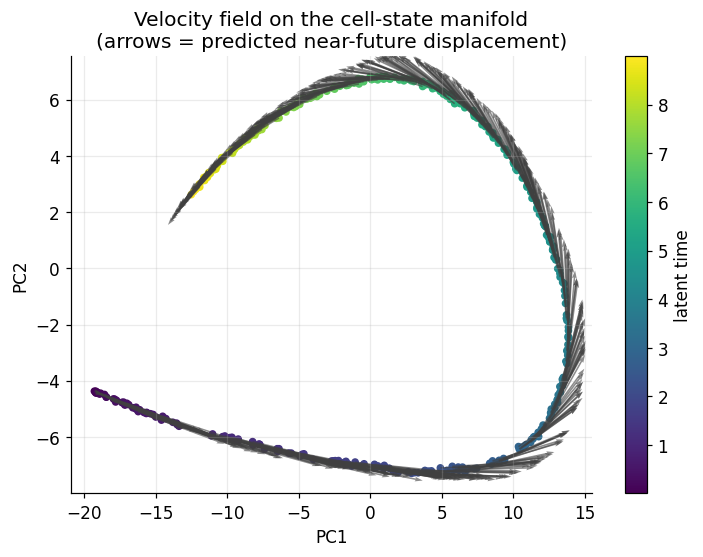

mean cosine(velocity, direction of increasing latent time) = +0.66


In [10]:
# PCA of spliced states; project velocity as the displacement to the predicted future state
Sc = S - S.mean(0)
Uu, sv, Vt = np.linalg.svd(Sc, full_matrices=False)
PC = Sc @ Vt[:2].T                                   # cells x 2
dt = 0.6
S_future = S + dt * Vel
PC_future = (S_future - S.mean(0)) @ Vt[:2].T
arrows = PC_future - PC

fig, ax = plt.subplots(figsize=(6.8, 5.2))
sc = ax.scatter(PC[:, 0], PC[:, 1], c=t_cell, cmap="viridis", s=16)
q = ax.quiver(PC[:, 0], PC[:, 1], arrows[:, 0], arrows[:, 1],
              angles="xy", scale_units="xy", scale=1, width=.003, alpha=.6, color="0.25")
plt.colorbar(sc, label="latent time")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Velocity field on the cell-state manifold\n(arrows = predicted near-future displacement)")
plt.tight_layout(); plt.show()

# quantify: does velocity align with increasing latent time?
order = np.argsort(t_cell)
forward = PC[order][1:] - PC[order][:-1]              # local "true" direction of time
cos = np.sum(arrows[order][:-1]*forward, 1) / (
      np.linalg.norm(arrows[order][:-1], axis=1)*np.linalg.norm(forward, axis=1) + 1e-9)
print(f"mean cosine(velocity, direction of increasing latent time) = {np.nanmean(cos):+.2f}")

The arrows flow consistently from early (dark) to late (yellow) latent time, and the mean cosine alignment with the true time direction is strongly positive — the high-dimensional velocity field has correctly recovered the direction of the process from a single static snapshot. In practice one converts this field into a **Markov transition matrix** on the cell graph (via the cosine kernel of the lecture notes) and reads off fate probabilities (CellRank, Lange et al. 2022).

## 7a. Estimating velocity I — the steady-state regression (La Manno et al.)

Assume the **upper-extreme** cells have reached steady state, $\dot s=0\Rightarrow u=\gamma s$ (with $\beta=1$). Fit $\gamma$ by least squares **through the origin** on those high-expression cells: minimize
$$J(\gamma)=\sum_{i\in\text{upper}}(u_i-\gamma s_i)^2.$$
Setting $J'(\gamma)=-2\sum_i s_i\,(u_i-\gamma s_i)=0$ gives the normal equation $\sum_i s_i u_i=\gamma\sum_i s_i^2$, hence the closed form
$$\boxed{\;\hat\gamma=\frac{\sum_i u_i s_i}{\sum_i s_i^2}\;},\qquad\text{then}\quad v_i=u_i-\hat\gamma\,s_i .$$
Fast and assumption-light — but biased when steady state is never reached (we see exactly that below).

steady-state estimate  gamma_hat = 0.619   (true 0.5)


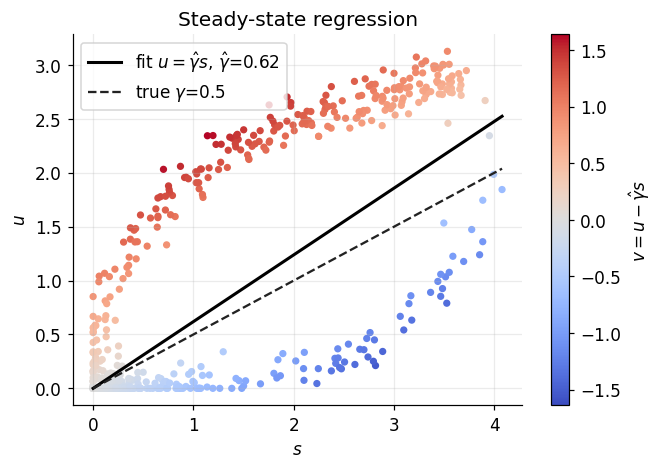

In [11]:
def steady_state_gamma(u, s, q=0.95):
    "Least-squares slope through the origin on the high-expression (near steady-state) cells."
    m = s >= np.quantile(s, q)              # upper extreme of the phase plot
    return np.sum(u[m]*s[m]) / np.sum(s[m]**2)

# one synthetic gene with known gamma
true = dict(alpha_on=3.0, gamma=0.5, t_s=3.0)
rng = np.random.default_rng(0)
Ncell = 500
t_lat = np.concatenate([rng.uniform(0, true["t_s"], Ncell//2),
                        rng.uniform(true["t_s"], true["t_s"]+12, Ncell//2)])
ug, sg, _ = model_curve(t_lat, **true)
Ud = np.clip(ug + rng.normal(0, 0.12, ug.shape), 0, None)
Sd = np.clip(sg + rng.normal(0, 0.12, sg.shape), 0, None)

g_hat = steady_state_gamma(Ud, Sd)
print(f"steady-state estimate  gamma_hat = {g_hat:.3f}   (true {true['gamma']})")

fig, ax = plt.subplots(figsize=(6.2, 4.4))
v_est = Ud - g_hat*Sd
sc = ax.scatter(Sd, Ud, c=v_est, cmap="coolwarm", s=14,
                vmin=-np.abs(v_est).max(), vmax=np.abs(v_est).max())
sl = np.linspace(0, Sd.max(), 30)
ax.plot(sl, g_hat*sl, "k-", lw=2, label=f"fit $u=\\hat\\gamma s$, $\\hat\\gamma$={g_hat:.2f}")
ax.plot(sl, true["gamma"]*sl, "--", color=C_TRUE, lw=1.5, label=f"true $\\gamma$={true['gamma']}")
plt.colorbar(sc, label="$v=u-\\hat\\gamma s$")
ax.set_xlabel("$s$"); ax.set_ylabel("$u$"); ax.set_title("Steady-state regression"); ax.legend()
plt.tight_layout(); plt.show()

Here $\hat\gamma\approx0.62$ **overshoots** the true $0.5$. That is the lesson, not a glitch: this gene switches off at $t_s=3$ *before* its induction phase plateaus, so it never reaches the upper steady state. The high-expression cells therefore sit on the **curved** part of the loop (near the switch point), not on the asymptote $u=\gamma s$, and the slope through them is too steep. This systematic bias in **transient** systems — ubiquitous in development — is exactly what motivates fitting the full trajectory next.

## 7b. Estimating velocity II — the EM / dynamical model (scVelo)

When steady state is **not** observed we fit the whole curve. Per gene the parameters are $\theta=(\alpha^{\mathrm{on}},\gamma,t_s)$ (with $\beta=1$); each cell $i$ has a latent time $t_i$ and phase $k_i\in\{\text{ind},\text{rep}\}$. Model the observation as Gaussian around the trajectory:
$$(u_i,s_i)\sim\mathcal N\!\big((\hat u(t_i;\theta,k_i),\hat s(t_i;\theta,k_i)),\ \sigma^2 I\big)
\ \Rightarrow\ -\log L=\frac{1}{2\sigma^2}\underbrace{\sum_i\big\|(u_i,s_i)-(\hat u,\hat s)\big\|^2}_{=:\,J(\theta,\{t_i,k_i\})}+\text{const}.$$
So maximum likelihood $=$ minimizing the sum of squared distances $J$.

**EM = block coordinate descent on $J$.**
- **E-step (fix $\theta$):** minimize $J$ over each $(t_i,k_i)$ separately $\Rightarrow$ assign every cell to its **nearest point on the model curve** (a projection onto the trajectory).
- **M-step (fix assignments):** minimize $J$ over $\theta$.

Each step can only lower $J$, and $J\ge0$, so $J^{(0)}\ge J^{(1)}\ge\cdots$ converges (monotone + bounded below). This is the *hard-assignment* limit of EM; replacing the argmin by a soft posterior over $t_i$ recovers full EM (e.g. veloVI). We initialize $\gamma$ from §7a and watch the fit evolve.

In [12]:
def reference_curve(theta, n=400, rep_horizon=8.0):
    a, g, ts = theta
    t_ind = np.linspace(0, ts, n)
    Trep = rep_horizon * max(1.0, 1.0/g)
    t_rep = np.linspace(ts, ts+Trep, n)
    times = np.concatenate([t_ind, t_rep])
    u, s, _ = model_curve(times, a, g, ts)
    return times, u, s

def e_step(U, S, theta):
    times, cu, cs = reference_curve(theta)
    d2 = (U[:, None]-cu[None, :])**2 + (S[:, None]-cs[None, :])**2
    j = np.argmin(d2, axis=1)
    return times[j], d2[np.arange(len(U)), j].sum()

def sse(theta, U, S, t_assign):
    a, g, ts = theta
    u, s, _ = model_curve(t_assign, a, g, ts)
    return np.sum((U-u)**2 + (S-s)**2)

def em_fit(U, S, theta0, n_iter=20):
    theta = np.array(theta0, float)
    hist = [theta.copy()]; objs = []
    for _ in range(n_iter):
        t_assign, obj = e_step(U, S, theta); objs.append(obj)
        res = minimize(sse, theta, args=(U, S, t_assign), method="L-BFGS-B",
                       bounds=[(1e-2, 20), (1e-2, 10), (1e-2, 15)])
        theta = res.x; hist.append(theta.copy())
    _, obj = e_step(U, S, theta); objs.append(obj)
    return theta, np.array(hist), np.array(objs)

theta0 = (np.quantile(Ud, 0.98), g_hat, 2.5)          # init from steady-state gamma
theta_hat, hist, objs = em_fit(Ud, Sd, theta0, n_iter=18)
print("init      (alpha, gamma, t_s) =", np.round(theta0, 3))
print("EM fit    (alpha, gamma, t_s) =", np.round(theta_hat, 3))
print("truth     (alpha, gamma, t_s) =", (true['alpha_on'], true['gamma'], true['t_s']))
print("objective:", objs[0].round(1), "->", objs[-1].round(1), " monotone:", bool(np.all(np.diff(objs) <= 1e-6)))

init      (alpha, gamma, t_s) = [2.969 0.619 2.5  ]
EM fit    (alpha, gamma, t_s) = [3.101 0.438 2.619]
truth     (alpha, gamma, t_s) = (3.0, 0.5, 3.0)
objective: 47.4 -> 4.8  monotone: True


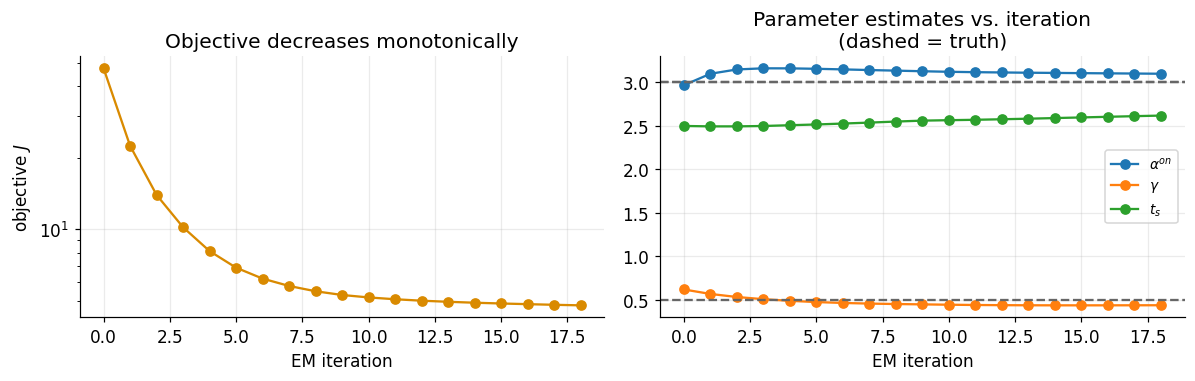

In [13]:
# convergence diagnostics
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(objs, "o-", color=C_FIT); ax[0].set_xlabel("EM iteration"); ax[0].set_ylabel("objective $J$")
ax[0].set_title("Objective decreases monotonically"); ax[0].set_yscale("log")

names = ["$\\alpha^{on}$", "$\\gamma$", "$t_s$"]
truth = [true['alpha_on'], true['gamma'], true['t_s']]
for k in range(3):
    ax[1].plot(hist[:, k], "o-", label=names[k])
    ax[1].axhline(truth[k], ls="--", color="0.4")
ax[1].set_xlabel("EM iteration"); ax[1].set_title("Parameter estimates vs. iteration\n(dashed = truth)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### GIF 3 — the model curve fitting the data over EM iterations

The grey points are the observed cells. The orange curve is the current model fit $\hat s(t),\hat u(t)$, redrawn from $\theta$ at each EM iteration; the dashed black curve is the ground truth. The title tracks the parameters and the objective.


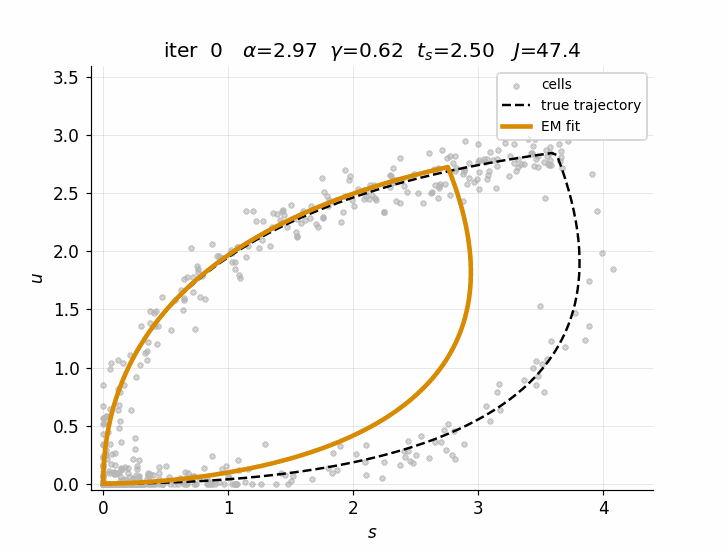

In [14]:
fig, ax = plt.subplots(figsize=(6.6, 5.0))
ax.scatter(Sd, Ud, s=12, color="0.7", alpha=.6, label="cells")
tt_true = np.linspace(0, true['t_s']+12, 400)
ut, st, _ = model_curve(tt_true, true['alpha_on'], true['gamma'], true['t_s'])
ax.plot(st, ut, "k--", lw=1.6, label="true trajectory")
fit_line, = ax.plot([], [], color=C_FIT, lw=3, label="EM fit")
ax.set_xlim(-.1, Sd.max()*1.08); ax.set_ylim(-.05, Ud.max()*1.15)
ax.set_xlabel("$s$"); ax.set_ylabel("$u$"); ax.legend(loc="upper right", fontsize=9)
ttl = ax.set_title("")

def upd(i):
    a, g, ts = hist[i]
    times, cu, cs = reference_curve((a, g, ts))
    fit_line.set_data(cs, cu)
    _, obj = e_step(Ud, Sd, hist[i])
    ttl.set_text(f"iter {i:2d}   $\\alpha$={a:.2f}  $\\gamma$={g:.2f}  $t_s$={ts:.2f}   $J$={obj:.1f}")
    return fit_line, ttl

# hold the final frame a little longer for readability
order = list(range(len(hist))) + [len(hist)-1]*6
anim = FuncAnimation(fig, upd, frames=order, interval=380, blit=False)
anim.save("03_em_convergence.gif", writer=PillowWriter(fps=3))
plt.close(fig)
show_gif("03_em_convergence.gif")

## 8. Identifiability — why velocity is only known up to a time scale

Notice in the parameter traces that the **curve** is pinned down quickly while individual parameters drift toward — but do not equal — the truth. Here is why. Rescale every rate by $c>0$ and time by $1/c$: set $\alpha'=c\alpha,\ \beta'=c\beta,\ \gamma'=c\gamma,\ t'=t/c$. By the chain rule,
$$\frac{du}{dt'}=\frac{du}{dt}\frac{dt}{dt'}=c\,(\alpha-\beta u)=\alpha'-\beta' u,\qquad
\frac{ds}{dt'}=c\,(\beta u-\gamma s)=\beta' u-\gamma' s.$$
So $(\alpha,\beta,\gamma)$ run on time $t$ and $(c\alpha,c\beta,c\gamma)$ run on time $t/c$ produce the **identical** trajectory in $(u,s)$ — snapshot data cannot tell them apart. Only dimensionless ratios (such as $\gamma/\beta$) and the *shape* of the curve are identifiable; absolute rates need an external clock (metabolic labelling, as in Dynamo). Hence splicing-based velocity is meaningful in **sign and relative magnitude**, not absolute units — and that is exactly why EM above nails the curve but not each parameter.

### Recap

| Concept | Where it appeared | Method / reference |
|---|---|---|
| Two-state ODE, closed form | §1–2 | mass action |
| Induction/repression loop, $\alpha^{on}/\alpha^{off}$ | §3 (GIF 1) | Bergen et al. 2020 |
| Velocity = distance from steady-state line | §4 | La Manno et al. 2018 |
| CME, Poisson steady state, SSA | §5 (GIF 2) | Gorin & Pachter 2022 |
| Velocity field on a manifold | §6 | CellRank, Lange et al. 2022 |
| Steady-state regression | §7a | La Manno et al. 2018 |
| EM / dynamical model | §7b (GIF 3) | Bergen et al. 2020 |
| Identifiability, absolute velocity | §8 | Gorin et al. 2022; Qiu et al. 2022 |

*Next steps to explore:* swap the Gaussian E-step for a full probabilistic posterior (veloVI, Gayoso et al. 2024); build the cosine transition matrix and compute absorption probabilities (CellRank); or couple snapshots across real time with optimal transport (Waddington-OT, Schiebinger et al. 2019).